In [2]:
import pandas as pd
import missingno
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from scipy.integrate import simps
import sys

sys.path.insert(0, "../Modules")

from preprocessing_utils import *

enc = 'utf-8' 

In [3]:
raw_data = pd.read_csv('data/IT_Veneto_WNV_cases_2008-2019.csv', encoding = enc)
raw_data.head(5)

,disease,municipality,province,onset of symptoms
0,WNND,Ficarolo,Rovigo,29-08-08
1,WNND,Cona,Venezia,20-08-09
2,WNND,Villadose,Rovigo,23-08-09
3,WNND,Fratta Polesine,Rovigo,04-09-09
4,WNND,Occhiobello,Rovigo,10-09-09


In [4]:
raw_data.shape

(298, 4)

In [5]:
data = raw_data.set_axis(['disease', 'lau1', 'nuts3', 'onset of symptoms'], axis=1, inplace=False)
data['nuts2'] = 'Veneto'

In [6]:
data.head(5)

,disease,lau1,nuts3,onset of symptoms,nuts2
0,WNND,Ficarolo,Rovigo,29-08-08,Veneto
1,WNND,Cona,Venezia,20-08-09,Veneto
2,WNND,Villadose,Rovigo,23-08-09,Veneto
3,WNND,Fratta Polesine,Rovigo,04-09-09,Veneto
4,WNND,Occhiobello,Rovigo,10-09-09,Veneto


In [7]:
df_missign = describe_dataframe(data)

df_missign

,Column,Missing
0,disease,0.0
1,lau1,0.0
2,nuts3,0.0
3,onset of symptoms,0.0
4,nuts2,0.0


In [8]:
data.shape

(298, 5)

In [9]:
data['onset of symptoms'] = pd.to_datetime(data['onset of symptoms'], dayfirst=True, errors='coerce')

In [10]:
data

,disease,lau1,nuts3,onset of symptoms,nuts2
0,WNND,Ficarolo,Rovigo,2008-08-29,Veneto
1,WNND,Cona,Venezia,2009-08-20,Veneto
2,WNND,Villadose,Rovigo,2009-08-23,Veneto
3,WNND,Fratta Polesine,Rovigo,2009-09-04,Veneto
4,WNND,Occhiobello,Rovigo,2009-09-10,Veneto
...,...,...,...,...,...
293,WNF,Santa Maria di Sala,VENEZIA,2019-09-20,Veneto
294,WNND,Vigodarzere,PADOVA,2019-09-26,Veneto
295,WNND,Caorle,VENEZIA,2019-09-26,Veneto
296,WNF,Noventa di Piave,VENEZIA,2019-10-05,Veneto


In [11]:
nuts2 = data['nuts2'].drop_duplicates().sort_values().tolist()
nuts3 = data['nuts3'].drop_duplicates().sort_values().tolist()
lau1 = data['lau1'].drop_duplicates().sort_values().tolist()

In [12]:
with open('data/IT_WNV_nuts2.txt', 'w', encoding=enc) as f:
    for item in nuts2:
        f.write("%s\n" % item)
        
with open('data/IT_WNV_nuts3.txt', 'w', encoding=enc) as f:
    for item in nuts3:
        f.write("%s\n" % item)
        
with open('data/IT_WNV_lau1.txt', 'w', encoding=enc) as f:
    for item in lau1:
        f.write("%s\n" % item)

<AxesSubplot:>

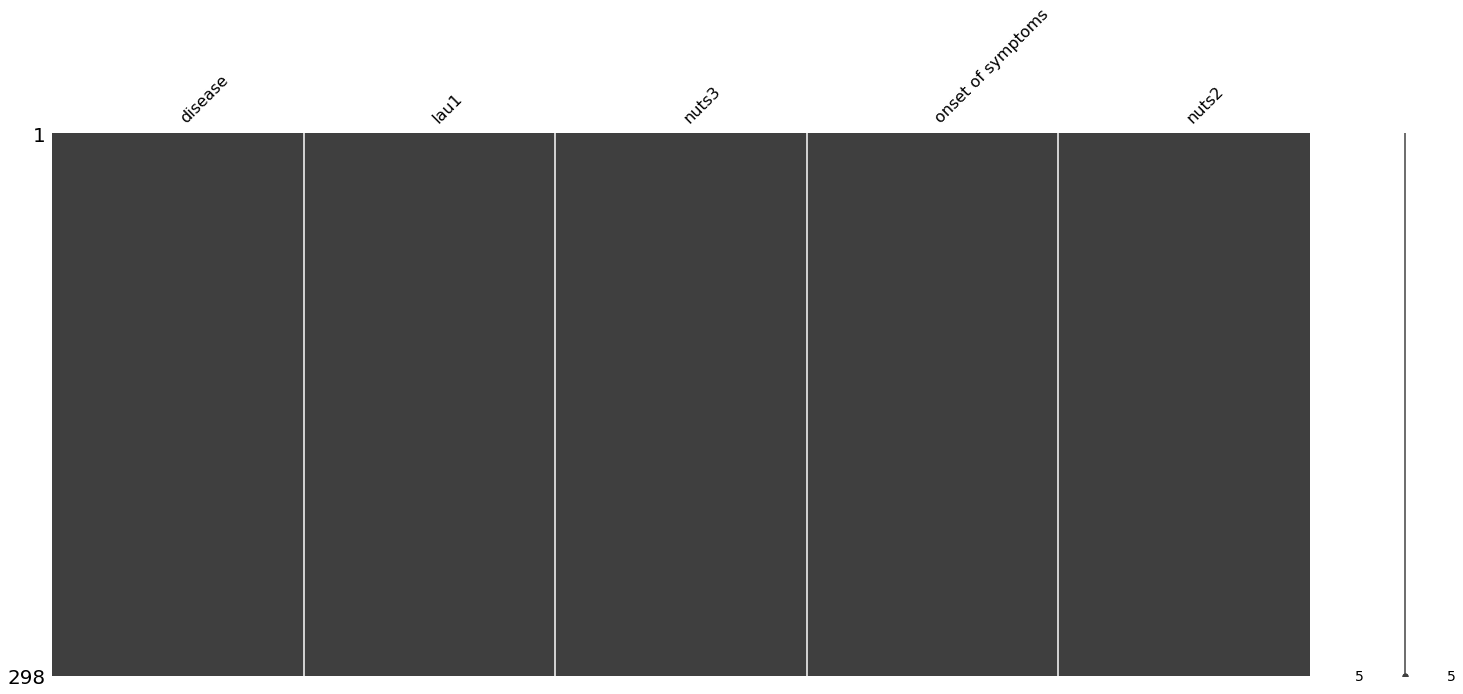

In [13]:
missingno.matrix(data)

In [14]:
process_italic(data, 'nuts2')
process_italic(data, 'nuts3')
process_italic(data, 'lau1')

In [15]:
data

,disease,lau1,nuts3,onset of symptoms,nuts2
0,WNND,ficarolo,rovigo,2008-08-29,veneto
1,WNND,cona,venezia,2009-08-20,veneto
2,WNND,villadose,rovigo,2009-08-23,veneto
3,WNND,fratta polesine,rovigo,2009-09-04,veneto
4,WNND,occhiobello,rovigo,2009-09-10,veneto
...,...,...,...,...,...
293,WNF,saint maria da sala,venezia,2019-09-20,veneto
294,WNND,vigodarzere,padova,2019-09-26,veneto
295,WNND,caorle,venezia,2019-09-26,veneto
296,WNF,noventa da piave,venezia,2019-10-05,veneto


In [16]:
data['day'] = data['onset of symptoms'].apply(lambda x : x.day)
data['month'] = data['onset of symptoms'].apply(lambda x : x.month)
data['year'] = data['onset of symptoms'].apply(lambda x : x.year)

In [17]:
nuts2_processed = data['nuts2'].drop_duplicates().sort_values().tolist()
nuts3_processed = data['nuts3'].drop_duplicates().sort_values().tolist()
lau1_processed = data['lau1'].drop_duplicates().sort_values().tolist()

In [18]:
with open('data/IT_WNV_nuts2_processed.txt', 'w', encoding=enc) as f:
    for item in nuts2_processed:
        f.write("%s\n" % item)
        
with open('data/IT_WNV_nuts3_processed.txt', 'w', encoding=enc) as f:
    for item in nuts3_processed:
        f.write("%s\n" % item)
        
with open('data/IT_WNV_lau1_processed.txt', 'w', encoding=enc) as f:
    for item in lau1_processed:
        f.write("%s\n" % item)

In [19]:
data

,disease,lau1,nuts3,onset of symptoms,nuts2,day,month,year
0,WNND,ficarolo,rovigo,2008-08-29,veneto,29,8,2008
1,WNND,cona,venezia,2009-08-20,veneto,20,8,2009
2,WNND,villadose,rovigo,2009-08-23,veneto,23,8,2009
3,WNND,fratta polesine,rovigo,2009-09-04,veneto,4,9,2009
4,WNND,occhiobello,rovigo,2009-09-10,veneto,10,9,2009
...,...,...,...,...,...,...,...,...
293,WNF,saint maria da sala,venezia,2019-09-20,veneto,20,9,2019
294,WNND,vigodarzere,padova,2019-09-26,veneto,26,9,2019
295,WNND,caorle,venezia,2019-09-26,veneto,26,9,2019
296,WNF,noventa da piave,venezia,2019-10-05,veneto,5,10,2019


In [20]:
data = data.reindex(columns=['onset of symptoms', 'year', 'month', 'day', 'nuts2', 'nuts3', 'lau1'])

In [21]:
data

,onset of symptoms,year,month,day,nuts2,nuts3,lau1
0,2008-08-29,2008,8,29,veneto,rovigo,ficarolo
1,2009-08-20,2009,8,20,veneto,venezia,cona
2,2009-08-23,2009,8,23,veneto,rovigo,villadose
3,2009-09-04,2009,9,4,veneto,rovigo,fratta polesine
4,2009-09-10,2009,9,10,veneto,rovigo,occhiobello
...,...,...,...,...,...,...,...
293,2019-09-20,2019,9,20,veneto,venezia,saint maria da sala
294,2019-09-26,2019,9,26,veneto,padova,vigodarzere
295,2019-09-26,2019,9,26,veneto,venezia,caorle
296,2019-10-05,2019,10,5,veneto,venezia,noventa da piave


In [22]:
df_missign = describe_dataframe(data)

df_missign

,Column,Missing
0,onset of symptoms,0.0
1,year,0.0
2,month,0.0
3,day,0.0
4,nuts2,0.0
5,nuts3,0.0
6,lau1,0.0


In [23]:
data.to_csv("data/IT_Veneto_WNV_cases_2008-2019_processed.csv", encoding = enc, index = False)

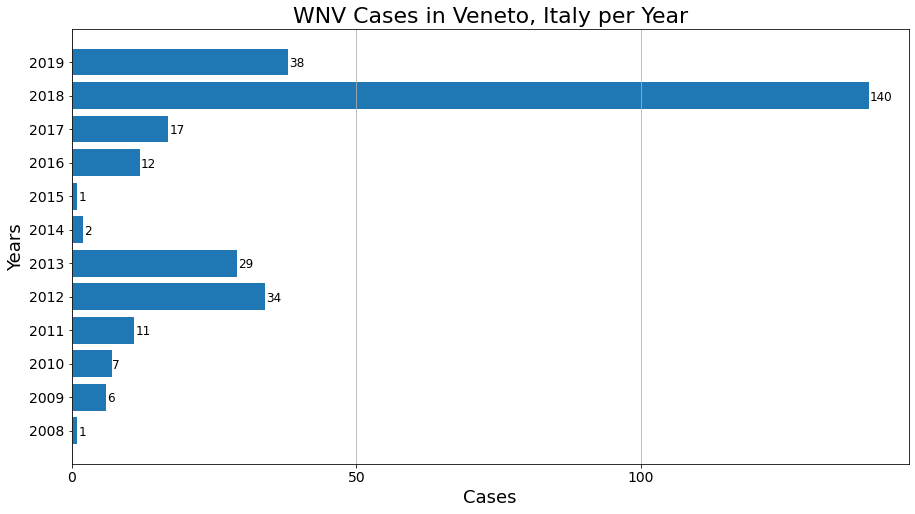

In [25]:
years = [year for year in range(2008, 2020)]
cases = [len(data.query(f"year == {year}")) for year in years]

plt.figure(num = None, figsize = (15,8), facecolor='w', edgecolor='b')
#plt.bar(years, cases)
plt.barh(years, cases)

#ax.bar_label(bars)
y_t = plt.xticks(np.arange(0, max(cases) + 10, step = 50), size = 14)
x_t = plt.yticks(np.arange(min(years), max(years) + 1, step = 1), size = 14)
x_l  = plt.ylabel('Years', size = 18)
y_l =  plt.xlabel('Cases', size = 18)
title = plt.title('WNV Cases in Veneto, Italy per Year', size = 22)
for year, case in zip(years,cases):
    plt.text(case+0.15, year-0.15, str(case), size = 12)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()